<a href="https://colab.research.google.com/github/aankit1729/spcx-vol-surface/blob/main/notebooks/01_surface_evolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — The implied volatility surface of a newly listed mega-cap

SpaceX (SPCX) listed in June 2026 with the largest first-day options volume on record.
This notebook builds its implied volatility surface from raw quotes and asks a simple
question: **does a stock with three months of price history get priced like a normal stock?**

SPY is the control — a mature, deeply liquid, heavily hedged underlying.

Run order: set `REPO` below, then Runtime → Run all.

In [1]:
REPO = "aankit1729/spcx-vol-surface"   # <-- your repo
TICKERS = ["SPCX", "SPY"]
RISK_FREE = 0.042

import sys, subprocess, os, shutil
shutil.rmtree("repo", ignore_errors=True)          # always start from a clean clone
subprocess.run(["git", "clone", "--depth", "1",
                f"https://github.com/{REPO}.git", "repo"], check=True)
sys.path.insert(0, "repo/src")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"], check=True)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from volsurface import bs, svi, clean, heston

# fail loudly if a stale module got cached
import inspect
assert "verbose" in inspect.signature(heston.calibrate).parameters, \
    "Stale heston.py — Runtime > Restart session, then run this cell again."

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})
print("ready —", len(list(Path("repo/data/raw").glob("*/*.parquet"))), "snapshots in repo")

ready — 3 snapshots in repo


## 1. Load the most recent snapshot

Each snapshot is one trading day's full option chain. Early on you have one file per
ticker; as the collector accumulates, this cell picks the latest.

In [2]:
RAW = Path("repo/data/raw")
snaps = {}
for t in TICKERS:
    files = sorted((RAW / t).glob("*.parquet"))
    if not files:
        print(f"{t}: no snapshots yet"); continue
    snaps[t] = pd.read_parquet(files[-1])
    print(f"{t}: {len(files)} snapshot(s), latest {files[-1].stem}, "
          f"{len(snaps[t])} contracts, spot {snaps[t]['spot'].iloc[0]:.2f}")

snaps[TICKERS[0]].head(3)

SPCX: 1 snapshot(s), latest 2026-09-09, 2788 contracts, spot 153.47
SPY: 1 snapshot(s), latest 2026-09-09, 9602 contracts, spot 765.96


,contractSymbol,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility,inTheMoney,lastTradeDate,cp,expiry,ticker,spot,snapshot_utc
0,SPCX260911C00010000,10.0,143.05,141.1,143.65,1.0,5,13.453127,True,2026-09-08 15:36:38+00:00,C,2026-09-11,SPCX,153.470001,2026-09-09 00:05:59.195560+00:00
1,SPCX260911C00015000,15.0,138.25,136.1,138.70,2.0,0,11.718753,True,2026-09-08 15:32:11+00:00,C,2026-09-11,SPCX,153.470001,2026-09-09 00:05:59.195560+00:00
2,SPCX260911C00020000,20.0,133.25,131.1,133.65,11.0,1,9.875004,True,2026-09-08 13:38:05+00:00,C,2026-09-11,SPCX,153.470001,2026-09-09 00:05:59.195560+00:00


## 2. Clean

What happens here matters more than the modelling, and it is the part interviewers probe.

- **Mid prices**, and drop any quote with no bid or a spread wider than 25% of mid.
  Zero-bid options are worthless-but-not-quite and their "prices" are noise.
- **Forward from put–call parity**, not `S·exp(rT)`. This absorbs dividends and, more
  importantly for SPCX, the borrow cost — which for a recent IPO with a lockup can be large.
- **OTM only**: calls above the forward, puts below. These are the liquid contracts, and
  it sidesteps early-exercise premium on American-style single stock options.
- **Recompute IV ourselves.** The `impliedVolatility` field from the data source is
  unreliable on thin strikes; we never use it.

In [3]:
cleaned, reports = {}, {}
for t, raw in snaps.items():
    c, rep = clean.clean_chain(raw, r=RISK_FREE, report=True)
    cleaned[t], reports[t] = c, rep
    print(f"\n=== {t} === session {clean.session_date(raw['snapshot_utc'].iloc[0]).date()}, "
          f"spot {c['spot'].iloc[0]:.2f}")
    print(rep.to_string())
    print(f"{c['T'].nunique()} expiries, IV range {c['iv'].min():.1%}-{c['iv'].max():.1%}, "
          f"front expiry {c['T'].min()*365.25:.1f}d")


=== SPCX === session 2026-09-08, spot 153.47
                      dropped  pct_of_raw
no two-sided quote      164.0         5.9
price below floor       131.0         4.7
spread too wide         318.0        11.4
illiquid                116.0         4.2
expired or too short      0.0         0.0
ITM (kept OTM only)    1112.0        39.9
IV inversion failed       0.0         0.0
beyond wing cutoff        4.0         0.1
KEPT                    943.0        33.8
18 expiries, IV range 52.6%-88.2%, front expiry 3.0d

=== SPY === session 2026-09-08, spot 765.96
                      dropped  pct_of_raw
no two-sided quote      486.0         5.1
price below floor       812.0         8.5
spread too wide          12.0         0.1
illiquid                411.0         4.3
expired or too short      0.0         0.0
ITM (kept OTM only)    3517.0        36.6
IV inversion failed       0.0         0.0
beyond wing cutoff     1162.0        12.1
KEPT                   3202.0        33.3
31 expiries, IV 

## 3. The smile, expiry by expiry

Log-moneyness `k = log(K/F)` on the x-axis so different expiries are comparable.
A downward slope is the equity skew: puts cost more than calls because crashes are
faster than rallies and because people buy protection.

Watch for whether SPCX's skew is *flatter* than SPY's — heavy retail call buying in a
hot new listing can bid up the right wing and partially offset the usual put skew.

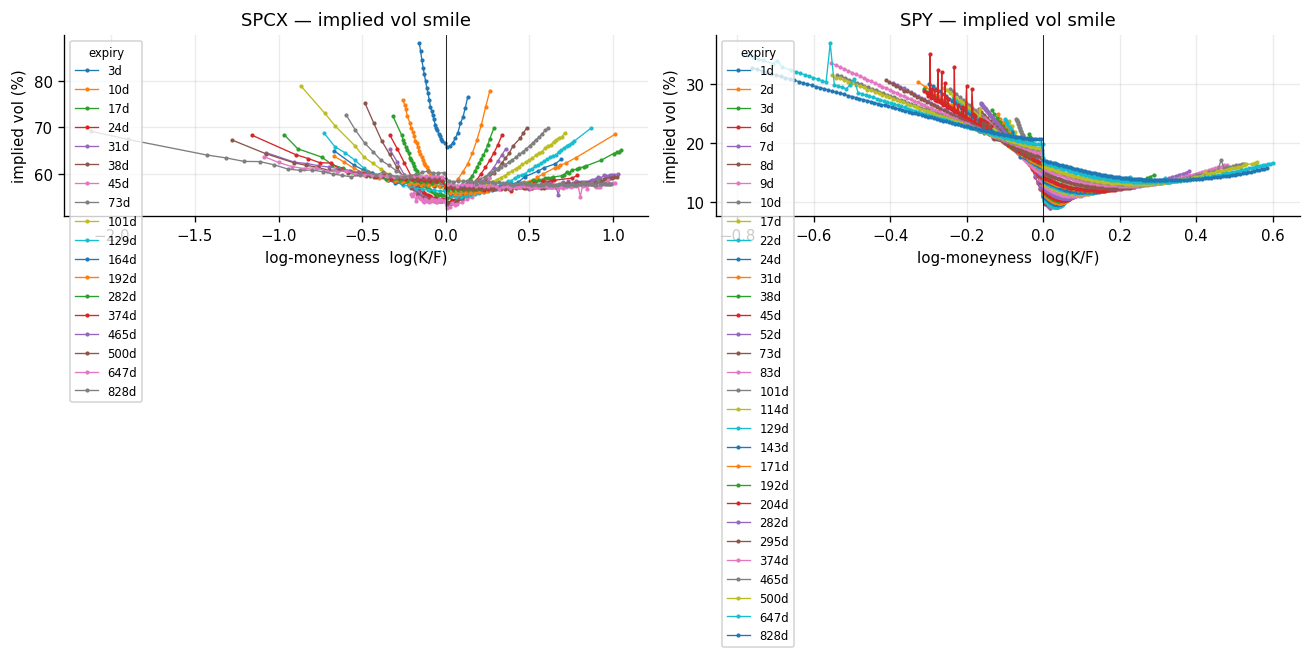

In [4]:
fig, axes = plt.subplots(1, len(cleaned), figsize=(5.5*len(cleaned), 4), squeeze=False)
for ax, (t, c) in zip(axes[0], cleaned.items()):
    for T, g in c.groupby("T"):
        ax.plot(g["k"], g["iv"]*100, ".-", ms=3, lw=.8, label=f"{T*365:.0f}d")
    ax.axvline(0, color="k", lw=.5)
    ax.set_title(f"{t} — implied vol smile"); ax.set_xlabel("log-moneyness  log(K/F)")
    ax.set_ylabel("implied vol (%)"); ax.legend(fontsize=7, title="expiry", title_fontsize=7)
plt.tight_layout(); plt.show()

## 4. Fit SVI to each slice

SVI (Gatheral) parameterises *total variance* `w(k) = σ²T` with five parameters:
level `a`, wing slope `b`, rotation `ρ`, translation `m`, and curvature `σ`.

Two arbitrage conditions get checked:
- **Butterfly** (Durrleman's `g(k) ≥ 0`): violated means the implied density goes
  negative somewhere — a call spread would have negative value.
- **Calendar**: total variance must not decrease with maturity, else you could buy
  the long option and sell the short one for a riskless profit.

A violation is not necessarily a bug in the fit. It can be stale quotes, a bad forward,
or — occasionally — a real dislocation. Investigate before you smooth it away.

In [5]:
fits = {}
for t, c in cleaned.items():
    rows = []
    for T, g in c.groupby("T"):
        w = g["fit_weight"].values
        p = svi.fit_slice(g["k"].values, g["iv"].values, T, weights=w)
        rows.append(dict(T=T, days=T*365.25, params=p, n=len(g),
                         k_lo=g["k"].min(), k_hi=g["k"].max(),
                         rmse_bp=svi.rmse_iv(g["k"].values, g["iv"].values, T, p, weights=w)*1e4,
                         butterfly_ok=svi.butterfly_arbitrage_free(p, k_range=(g["k"].min(), g["k"].max())),
                         atm_vol=float(svi.implied_vol(0.0, T, p))))
    f = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
    # calendar check only where BOTH slices have data
    cal = [True]
    for i in range(1, len(f)):
        lo = max(f["k_lo"][i-1], f["k_lo"][i]); hi = min(f["k_hi"][i-1], f["k_hi"][i])
        cal.append(svi.calendar_arbitrage_free(f["params"][i-1], f["params"][i], k_range=(lo, hi))
                   if hi > lo else True)
    f["calendar_ok"] = cal
    fits[t] = f
    print(f"\n{t}")
    print(f[["days","n","k_lo","k_hi","atm_vol","rmse_bp","butterfly_ok","calendar_ok"]]
          .round(4).to_string(index=False))



SPCX
 days  n    k_lo   k_hi  atm_vol  rmse_bp  butterfly_ok  calendar_ok
  3.0 30 -0.1583 0.1312   0.6611  19.4529          True         True
 10.0 40 -0.2551 0.2641   0.5725  19.3670          True         True
 17.0 54 -0.3160 0.2885   0.5499  25.0936          True         True
 24.0 46 -0.3350 0.3352   0.5405  22.4952          True         True
 31.0 46 -0.3355 0.3577   0.5371  28.1897          True         True
 38.0 31 -0.4830 0.4845   0.5366  26.2235          True         True
 45.0 37 -0.2086 0.2614   0.5370  37.6820          True         True
 73.0 41 -0.5974 0.6125   0.5737  32.2977          True         True
101.0 49 -0.8679 0.7103   0.5647  47.7425          True         True
129.0 54 -0.7282 0.8678   0.5558  35.6680          True         True
164.0 37 -0.6660 0.6886   0.5647  45.9239          True         True
192.0 46 -0.6690 1.0128   0.5652  43.1740          True         True
282.0 62 -0.9659 1.0490   0.5722  45.6279          True         True
374.0 52 -1.1596 0.7864   0.

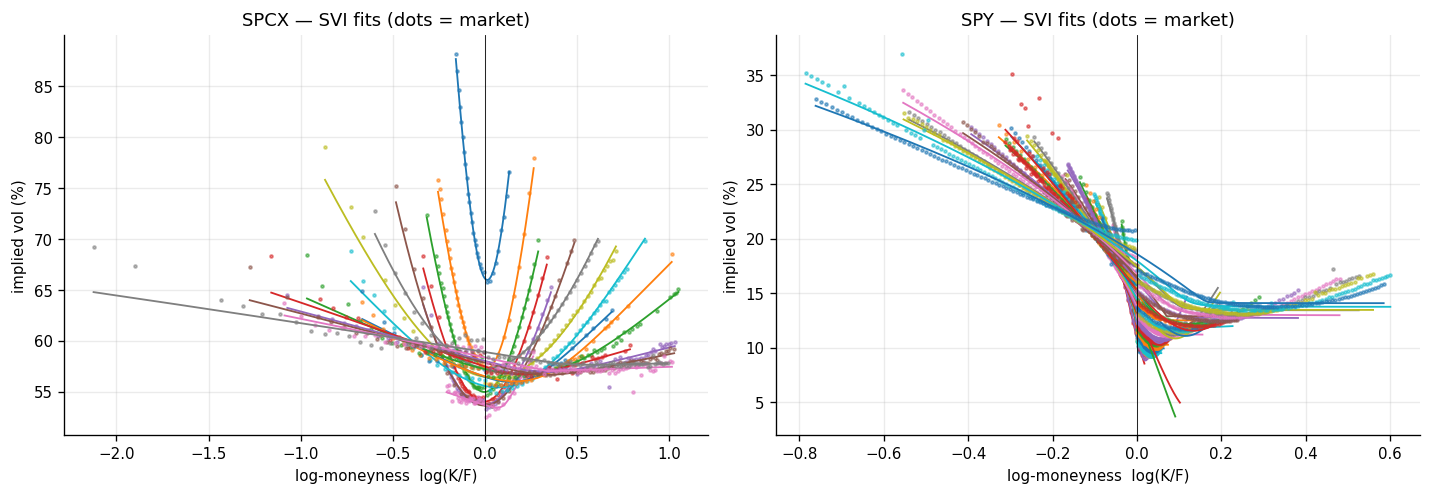

In [6]:
fig, axes = plt.subplots(1, len(cleaned), figsize=(6*len(cleaned), 4.2), squeeze=False)
for ax, (t, c) in zip(axes[0], cleaned.items()):
    for _, row in fits[t].iterrows():
        g = c[c["T"] == row["T"]]
        kk = np.linspace(row["k_lo"], row["k_hi"], 200)      # own range only
        l, = ax.plot(kk, svi.implied_vol(kk, row["T"], row["params"])*100, lw=1.1)
        ax.plot(g["k"], g["iv"]*100, ".", ms=3.5, color=l.get_color(), alpha=.55)
    ax.axvline(0, color="k", lw=.5)
    ax.set_title(f"{t} — SVI fits (dots = market)")
    ax.set_xlabel("log-moneyness  log(K/F)"); ax.set_ylabel("implied vol (%)")
plt.tight_layout(); plt.show()




## 5. Term structure and skew

Two numbers summarise a surface. **ATM vol by expiry** shows whether the market expects
near-term turbulence to fade (downward sloping) or build (upward). **Skew**, measured as
the 25-delta put vol minus the 25-delta call vol, shows the asymmetry.

For SPCX, look for humps in the term structure at expiries spanning known events —
lockup expiry and index inclusion both concentrate uncertainty on a date.

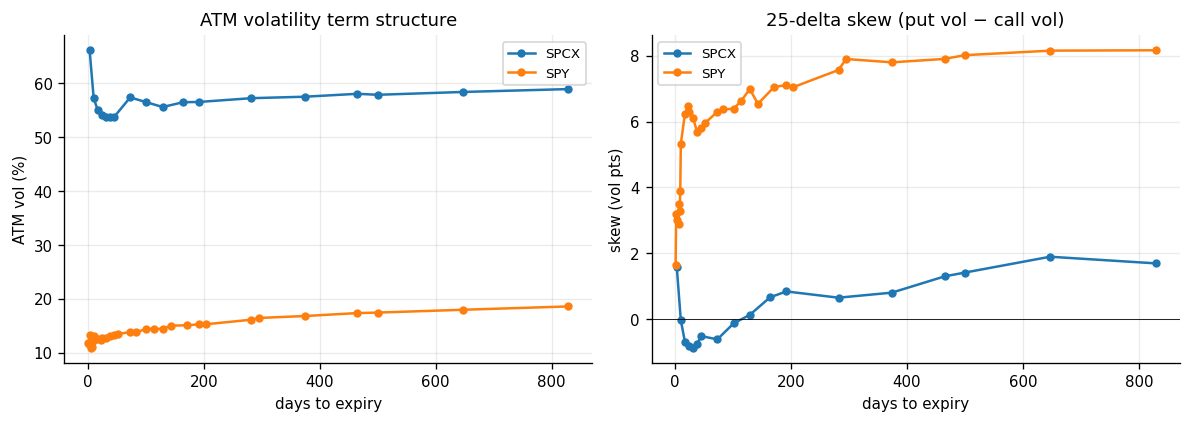

In [7]:
def delta_strike_vol(T, p, target_delta, cp, S, r):
    """IV at the strike whose BS delta equals target_delta, solved on the SVI slice."""
    kk = np.linspace(-1.2, 1.2, 2000)
    iv = svi.implied_vol(kk, T, p)
    F = S*np.exp(r*T); K = F*np.exp(kk)
    d = bs.delta(S, K, T, r, 0.0, iv, cp)
    i = np.argmin(np.abs(np.abs(d) - target_delta))
    return float(iv[i])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for t, c in cleaned.items():
    S = float(c["spot"].iloc[0]); f = fits[t]
    axes[0].plot(f["days"], f["atm_vol"]*100, "o-", ms=4, label=t)
    sk = [ (delta_strike_vol(r_.T, r_.params, .25, -1, S, RISK_FREE)
            - delta_strike_vol(r_.T, r_.params, .25, +1, S, RISK_FREE))*100
           for r_ in f.itertuples() ]
    axes[1].plot(f["days"], sk, "o-", ms=4, label=t)
axes[0].set_title("ATM volatility term structure"); axes[0].set_ylabel("ATM vol (%)")
axes[1].set_title("25-delta skew (put vol − call vol)"); axes[1].set_ylabel("skew (vol pts)")
axes[1].axhline(0, color="k", lw=.5)
for a in axes: a.set_xlabel("days to expiry"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Calibrate Heston to the whole surface

SVI fits each expiry independently — five parameters per slice, so a surface with six
expiries costs thirty parameters and says nothing about dynamics. Heston uses five
parameters for the *entire* surface and comes with a stochastic process, which is what
lets us compute a hedge ratio in notebook 04.

The fit will be visibly worse than SVI. That is the point: SVI describes, Heston explains.
Where Heston fails tells you which features of the surface a mean-reverting square-root
variance process cannot generate — typically the very short-dated smile, which needs jumps.

In [8]:
hfits = {}
for t, c in cleaned.items():
    S = float(c["spot"].iloc[0])
    chain = (c.drop(columns=["cp"])
               .rename(columns={"strike": "K", "cpi": "cp"})[["T", "K", "iv", "cp", "k"]])
    calib = heston.subsample_surface(chain, S=S, r=RISK_FREE)
    print(f"{t}: {len(chain)} quotes -> calibrating on {len(calib)} "
          f"({calib['T'].nunique()} expiries, {calib['T'].min()*365.25:.0f}-{calib['T'].max()*365.25:.0f}d)")
    p = heston.calibrate(chain, S, RISK_FREE, 0.0, verbose=True)
    hfits[t] = p
    print(f"{t}:  v0={p.v0:.4f} (vol {np.sqrt(p.v0):.1%})  kappa={p.kappa:.2f}  "
          f"theta={p.theta:.4f} (vol {np.sqrt(p.theta):.1%})  xi={p.xi:.3f}  rho={p.rho:+.3f}")
    print(f"      Feller 2*kappa*theta - xi^2 = {p.feller():+.4f}"
          f"{'  (satisfied)' if p.feller() > 0 else '  (violated: variance can reach zero)'}")
    print(f"      RMSE on calibration window = {heston.surface_rmse_bp(calib, S, RISK_FREE, 0.0, p):.0f} bp")
    print(f"      RMSE on full surface       = {heston.surface_rmse_bp(chain, S, RISK_FREE, 0.0, p):.0f} bp\n")


SPCX: 943 quotes -> calibrating on 250 (10 expiries, 10-374d)
    eval   25  rmse   299.8 bp
    eval   50  rmse   199.1 bp
    eval   75  rmse   199.1 bp
    eval  100  rmse   411.9 bp
    eval  125  rmse   230.5 bp
    eval  150  rmse   199.1 bp
    eval  175  rmse   199.1 bp
    eval  200  rmse   199.1 bp
    eval  225  rmse   199.1 bp
    eval  250  rmse   216.7 bp
    eval  275  rmse   199.1 bp
    eval  300  rmse   199.1 bp
    eval  325  rmse   351.7 bp
    eval  350  rmse   258.8 bp
    eval  375  rmse   199.4 bp
    eval  400  rmse   199.1 bp
    done: 421 evals over 4 start(s), status 4
SPCX:  v0=0.3327 (vol 57.7%)  kappa=7.19  theta=0.3586 (vol 59.9%)  xi=3.000  rho=-0.034
      Feller 2*kappa*theta - xi^2 = -3.8427  (violated: variance can reach zero)
      RMSE on calibration window = 233 bp
      RMSE on full surface       = 330 bp

SPY: 3202 quotes -> calibrating on 224 (10 expiries, 6-374d)
    eval   25  rmse    59.9 bp
    eval   50  rmse    54.0 bp
    eval   75  rms

## 7. What to write down

Fill these in from your own output — this becomes the README summary and the thing you
actually talk about in an interview:

1. Is SPCX's ATM vol level plausible for a mega-cap, or is it trading like a small cap?
2. Is the skew steeper or flatter than SPY's, and does the retail-call-buying story hold up?
3. Does the term structure have a bump at the lockup expiry or index inclusion date?
4. Where does Heston fail worst — short expiries, deep wings, or both?
5. Any arbitrage violations, and are they real or artefacts of thin quotes?

**Next:** `03_variance_risk_premium` once you have a few weeks of snapshots, since it
needs implied vol today compared against realised vol later.